In [282]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd 

# **Sintetización Monte Carlo de la silueta de un agujero negro con Ray Tracing (Aproximación Eikonal)**

En este notebbook se realiza un a simulacion de las consecuencias opticas la presencia de un agujero negro en la trayectoria de una fuente de luz esferica. No se tendran en cuenta ecuaciones de movimiento de geometria diferencial. Solo se tiene en cuenta la **aproximación Eikonal**; en este método los rayos de luz se tratan como si se propagaran a traves de un medio en el que la velocidad de la luz es inversamente proporcional a un indice de refraccion $n(\vec{r})=n(x,y)$. En esta aproximación el espacio-tiempo alrededor de un agujero negro se modela mediante un indice de refraccion radial:


$$
n(r)= \frac{1}{1-\frac{A}{r}}, \quad r=\sqrt{x^2 + y^2}
$$

Donde $A$ es una constante correspondiente al radio gravitacional del agujero negro. 

Los rayos de luz se curvan hacia el centro a medida que r → A. Es conveniente introducir un factor de corrección a este  ́ındice para lograr una mejor aproximación a lo predicho por la relatividad general, asi:

$$
corr = \left|1 - \frac{9}{8} (\frac{A}{r})^2\right|
$$

A continuacion se definen las funciones numericas:

In [283]:
rf = lambda x, y: np.sqrt(x**2 + y**2)

# indice de refraccion de aproximacion eikonal
nf = lambda x, y, rmax, eps: 1/ (1 - rmax / (r(x, y)+ eps))

# Falctor de correccion
corrf = lambda x, y, rmax: np.abs(1 - 9/8 * (rmax/ r(x, y))**2)


Las ecuaciones que describen la trayectoria $(x, y)$ y la velocidad $(v_x, v_y)$ de un rayo en esta aproximación viene dada por: 

$$
\frac{dx}{dt} = \frac{v_x}{n(x, y)} \quad \wedge \quad \frac{dy}{dt} = \frac{v_y}{n(x,y)}
$$

y:

$$
\frac{d\, v_x}{dt} = \frac{\partial }{\partial x} n(x, y) \quad \wedge \quad \frac{d\,v_y}{dt} = \frac{\partial}{\partial y} n(x, y)
$$

In [284]:
# definimos las ecuaciones diferenciales que modelan la trayectoria de la luz

def refindex(x, y, A=10):
    eps = 1e-5

    r = rf(x, y)

    n = nf(x, y, A, eps)

    fac = corrf(x, y, A)

    nx = -fac * n**2 * A * x / (r + eps)**3
    ny = -fac * n**2 * A * y / (r + eps)**3

    return n, nx, ny


def flow_deriv(t, state):
    x, y, vx, vy = state

    n, nx, ny = refindex(x, y)

    deriv = np.zeros(4)

    deriv[0] = vx / n
    deriv[1] = vy / n
    deriv[2] = nx
    deriv[3] = ny

    return deriv


## **integración de rayos en el plano $x-y$**

A continuación, generaremos puntos aleatorios uniformemente distribuidos en un circulo de radio $r$ ubicado en el plano coordenado $x-y$, los cuales corresponderan a puntos de una fuente de luz esférica, corresponderan a los valores iniciales. 


In [285]:
N = 10000 # numero de posiciones iniciales a generar
R = 70 # radio sugerido

# Generamos posiciones iniciales aleatorias dentro de un círculo de radio R
theta = np.random.uniform(0, 2*np.pi, N)
rs = R * np.sqrt(np.random.uniform(0, 1, N))

# posiciones cartesianas en el plano y-z
y = rs * np.cos(theta)
z = rs * np.sin(theta)
x = np.zeros(N)  # eje x

# lo convertimos a coordenadas cilindricas
rs = np.sqrt(x**2 + y**2 + z**2)


**Visualizemos las posiciones iniciales generadas aleatoriamente**

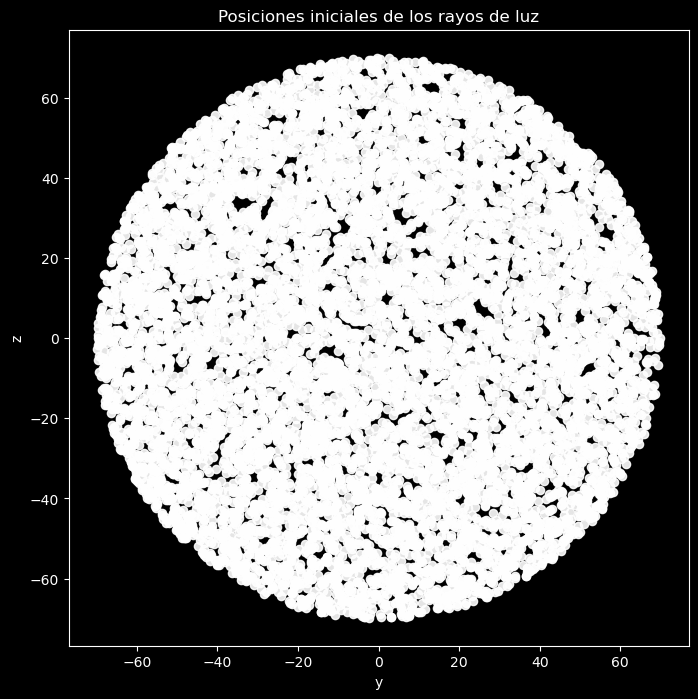

In [286]:
# visualizacion de los puntos en el plano

plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(y, z, s=35, c='white', alpha=0.9)
plt.title('Posiciones iniciales de los rayos de luz', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/posiciones_iniciales_aleatorias.png', dpi=300, bbox_inches='tight')
plt.show()

## **Integración de rayos en plano $x-y$**

Ya tenemos las distancias radiales a al centro del plano coordenado $y-z$. A continuacion vamos a simular una situacion en la que hay una fuente de luz en el plano $y-z$ alejado a una distancia $x=-100$ de un agujero negro. Vamos a ver desde la perspectiva del plano $x-y$ como se deforma la trayectoria de los rayos de luz que se desplazan a una velocidad $(\vec{v}_0 = [1, 0])$ en el plano $x-y$ debido a la presencia de este agujero negro. Para esto resolvemos las ecuaciones planteadas anteriormente.

**Asi, resolvemos la ecuación en la aproximación Eikonal para todos los rayos de luz.**

Aqui tomamos como condiciones iniciales para cada rayo de luz: 
- $x=-100$ 
- $y=r$ (Distancias radiales generadas aleatoriamente) 
- $v_x=1$ (Velocidad horizontal)
- $v_y= 0$ (Sin velocidad vertical)

Se integrara la trayectoria de los rayos de luz en intervalo de tiempo de $t \in [0, 400]$ con $\Delta t = 1$.


In [287]:
# inicializamos el proceso de integración para la aproximacion eikonal
x0, y0 = -100*np.ones(N), rs

tspan = [0, 400]

# array detiempo con paso 1
ts = np.arange(0, 400, 1)

Con esto, resolvemos numericamente la función `flow_deriv` usando `solve_ivp` de *scipy*. También, vamos a truncar la simulación para cada rayo cuando $r = A$ usando la opcion de `events` en `solve_ivp`; Esto debido a que alli diverge nuestro modelo para $n$ y significará que el agujero negro ha absorbido ese rayo de luz.

In [288]:
xs = []
ys = []
eventos = []

def event_horizon(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)

    return r - 10  # radio del horizonte de eventos

event_horizon.terminal = True
event_horizon.direction = -1

for i in range(N):
    sol = solve_ivp(
        lambda t, state: flow_deriv(t, state),
        tspan,
        np.array([-100.0, rs[i], 1.0, 0.0]),
        t_eval=ts,
        events=event_horizon
    )

    xs.append(sol.y[0])
    ys.append(sol.y[1])
    eventos.append(sol.t_events[0][0] if sol.t_events[0].size > 0 else np.nan)  # Guardamos el tiempo del evento o NaN si no ocurrió

comprobacion_ext = np.zeros(N, dtype=bool)
for i in range(N):
    comprobacion_ext[i] = np.max(xs[i]) > 300

print("Número de rayos que se alejan extremadamente (x>300) del agujero negro son:", np.sum(comprobacion_ext))

Número de rayos que se alejan extremadamente (x>300) del agujero negro son: 0


**Graficamos la trayectoria de los rayos de luz**

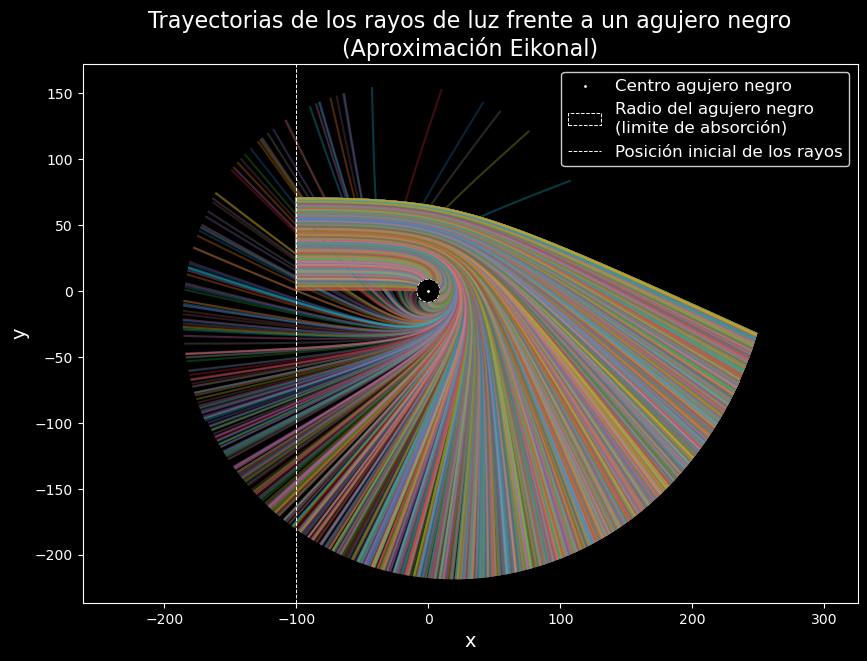

In [289]:
plt.figure(figsize=(10, 7), facecolor='black')


ax = plt.gca()
ax.set_facecolor('black')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
ax.set_aspect('equal', adjustable='box')

plt.scatter(0, 0, s=1, c='white', marker='o',
            label='Centro agujero negro', zorder=5)

circulo = plt.Circle((0, 0), 8.8, color='white', label='Radio del agujero negro\n(limite de absorción)',
                     fill=False, linestyle='--', linewidth=0.7)
ax.add_patch(circulo)

for i in range(N):
    plt.plot(xs[i], ys[i], alpha=0.3)

plt.title('Trayectorias de los rayos de luz frente a un agujero negro\n(Aproximación Eikonal)', fontsize=16, color='white')
plt.xlabel('x', fontsize=14, color='white')
plt.ylabel('y', fontsize=14, color='white')
plt.axvline(-100, color='white', linestyle='--', linewidth=0.7, label='Posición inicial de los rayos')
plt.tick_params(colors='white')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.axis('equal')  
plt.legend(loc='upper right', fontsize=12, facecolor='black', edgecolor='white', labelcolor='white')
#plt.savefig('imagenes_bacanas/trayectorias.png', dpi=300, bbox_inches='tight')
plt.show()

In [290]:
eventos = np.array(eventos)  # Convertimos a un array de objetos para manejar listas de diferentes longitudes
eventos = eventos[~np.isnan(eventos)]  # Filtramos los eventos que no ocurrieron (NaN)


In [291]:
print(f"El agujero negro absorbió {len(eventos)} rayos de luz de los {N} rayos iniciales.")
print(f"El agujero negro absorbió un aproximado del {len(eventos)/N*100:.2f}% de los rayos de luz.")

El agujero negro absorbió 2632 rayos de luz de los 10000 rayos iniciales.
El agujero negro absorbió un aproximado del 26.32% de los rayos de luz.


## **Construcción de un disco inclinado**
Ahora, vamos a generar un disco con puntos, simulando la presencia de un disco de acreción delgado alrededor del agujero negro. 

Para esto vamos a generar un numero $N$ de posiciones iniciales aleatorias distribuidas uniformemente dentro de un anillo con radio interno $R_{in}$ y radio externo $R_{ext}$.

In [292]:
# definimos los parametros para la generacion del disco
Nd = 7000   # Numero de particulas en el disco
Rin = 15    # Radio interno del disco
Rext = 50   # Radio externo del disco

# generamos posiciones aleatorias para las particulas del disco
theta_d = np.random.uniform(0, 2*np.pi, Nd)
rds = np.sqrt(np.random.uniform(Rin**2, Rext**2, Nd)) 

# lo convertimos a coordenadas cartesianas
yd = rds * np.cos(theta_d)
zd = rds * np.sin(theta_d)



el espaciamiento promedio entre puntos del disco viene dado por:

$d_{ave} \approx \sqrt{\frac{\pi R_{out}^2}{N_d}}$

In [293]:
d_ave = np.sqrt(np.pi * (Rext**2) / Nd)  # distancia promedio entre particulas
print(f"La distancia promedio entre particulas del disco es: {d_ave:.2f}")

La distancia promedio entre particulas del disco es: 1.06


**Vizualizemos el disco generado en primera instancia:**

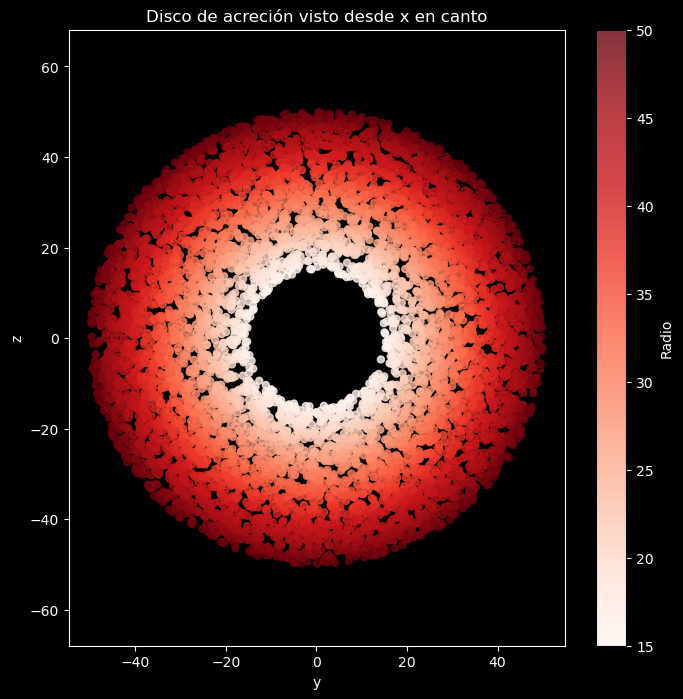

In [294]:
plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(yd, zd, s=25, c=rds, cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label('Radio', color='white')
cbar.ax.tick_params(colors='white')

plt.title('Disco de acreción visto desde x en canto', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/disco_acresión.png', dpi=300, bbox_inches='tight')
plt.show()


Vamos a inclinar el disco de acresión con respecto a nosotros a un ángulo $i = 20 °$ con ayuda de la funcion para rotaciones (`scipy.spatial.transform.Rotation`).

In [295]:
from scipy.spatial.transform import Rotation as R

puntos = np.column_stack((yd, zd, np.zeros(Nd)))  # Convertimos a un array de Nx3
rot = R.from_euler('y', 20, degrees=True)

puntos_rotados = rot.apply(puntos)

yd_rot = puntos_rotados[:, 1]
zd_rot = puntos_rotados[:, 2]

Veamos como cambia la perspectiva **graficando de nuevo el disco**

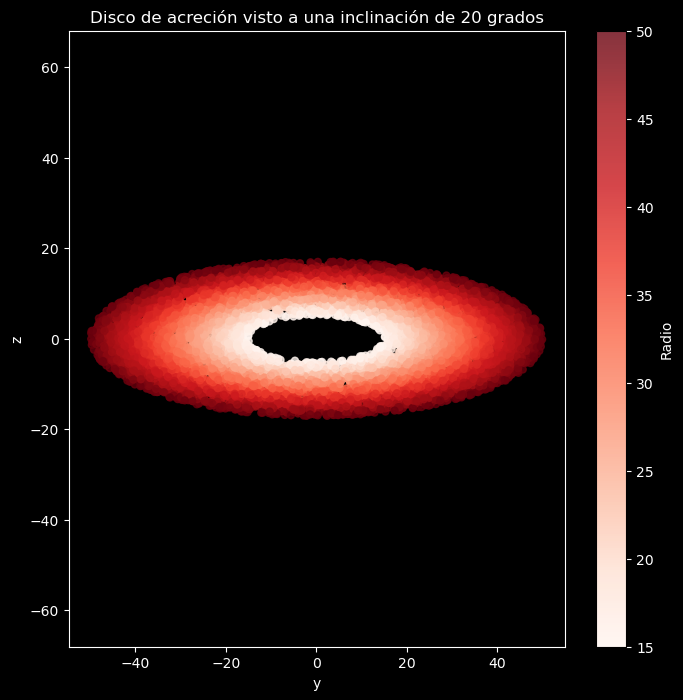

In [296]:
plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(yd_rot, zd_rot, s=25, c=rds, cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label('Radio', color='white')
cbar.ax.tick_params(colors='white')

plt.title('Disco de acreción visto a una inclinación de 20 grados', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/disco_acresión_inclinado.png', dpi=300, bbox_inches='tight')
plt.show()

## **Intersecciones Rayo-Disco en 3D y Síntesis de la imagen**

Para determinar si un rayo contribuye a la imagen observada es necesario comprobar si intersecta al disco inclinado que simulamos anteriormente. Pa lograr esto, tenemos que rotar cada rayo al $\theta$ original.

A continuación se realiza una función que devuelva una matriz de rotación al rededor del eje $x$ en un ángulo $\theta$

In [297]:
# Se realiza una funcion de rotacion en el eje x
R_x_theta = lambda theta: np.array([[1, 0, 0],
                                    [0, np.cos(theta), -np.sin(theta)],
                                    [0, np.sin(theta), np.cos(theta)]])

Con nuestra función `R_x_theta` rotamos la trayectoria de cada rayo de luz y comprobamos si intersecta con el disco de acresión.

In [298]:
# A continuacion, rotamos cada trayectoria de los rayos de luz en el eje x para cada uno de los N rayos
zs_rotadas = []
ys_rotadas = []
xs_rotadas = []

for i in range(N):
    trayectoria = np.column_stack((xs[i], ys[i], np.zeros_like(xs[i])))
    trayectoria_rotada = R_x_theta(theta[i]).dot(trayectoria.T).T   # theta0[i], en radianes
    xs_rotadas.append(trayectoria_rotada[:, 0])
    ys_rotadas.append(trayectoria_rotada[:, 1])
    zs_rotadas.append(trayectoria_rotada[:, 2])



Comprobamos que la rotación es correcta comparando los valores inicales rotados con los valores iniciales

In [299]:
print(xs_rotadas[0][0], ys_rotadas[0][0], zs_rotadas[0][0])
print(-100, y[0], z[0])  
# Comprobamos que la rotacion es correcta para el primer rayo
print("Se comprueba que la rotación es correcta para el primer rayo: ", np.allclose(xs_rotadas[0][0], -100) and np.allclose(ys_rotadas[0][0], y[0]) and np.allclose(zs_rotadas[0][0], z[0]))

-100.0 56.03128729037541 16.573957576275905
-100 56.03128729037541 16.573957576275905
Se comprueba que la rotación es correcta para el primer rayo:  True


Ahora, realizamos la comprobación de que el rayo interseca el disco de acresión:

In [300]:
from scipy.spatial import cKDTree

def intersecta_disco(xs, ys, zs, puntos_disco, d_ave):
    """
    Para cada rayo devuelve el radio (respecto al agujero negro) del punto del
    disco que golpea, o -999 si no lo golpea.
    xs, ys, zs: listas de arreglos, uno por rayo (trayectorias ya rotadas a 3D)
    puntos_disco: arreglo (Nd, 3) con el disco ya inclinado
    """

    N = len(xs)
    radio_impacto = np.full(N, -999.0)
    arbol = cKDTree(puntos_disco)            # se construye una sola vez

    for i in range(N):
        pts = np.column_stack((xs[i], ys[i], zs[i]))
        # distancia al vecino más cercano de cada punto del rayo;
        # si no hay ninguno a menos de d_ave, devuelve dist = inf
        dist, idx = arbol.query(pts, distance_upper_bound=d_ave)
        golpes = np.where(np.isfinite(dist))[0]

        if golpes.size > 0:
            primero = golpes[0]              # primer impacto a lo largo del rayo
            radio_impacto[i] = np.linalg.norm(puntos_disco[idx[primero]])

    return radio_impacto

intersecciones = intersecta_disco(xs_rotadas, ys_rotadas, zs_rotadas, puntos_rotados, d_ave)

In [301]:
golpeo = intersecciones > 0
print(f"{golpeo.sum()} de {N} rayos golpean el disco")

3061 de 10000 rayos golpean el disco


Text(0, 0.5, 'z')

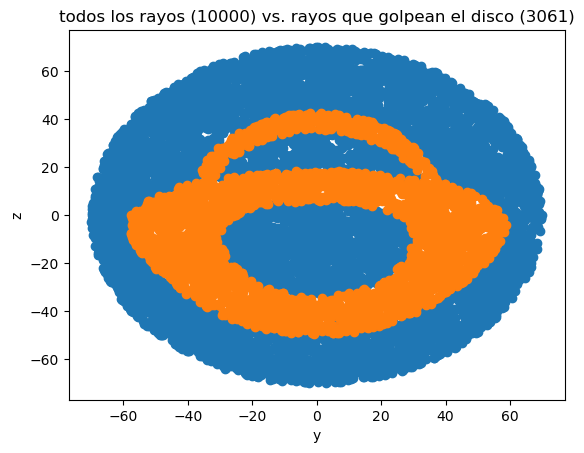

In [302]:
plt.scatter(y[~golpeo], z[~golpeo], color='tab:blue')
plt.scatter(y[golpeo],  z[golpeo],  color='tab:orange')
plt.title(f'todos los rayos ({N}) vs. rayos que golpean el disco ({golpeo.sum()})')
plt.xlabel('y'); plt.ylabel('z')

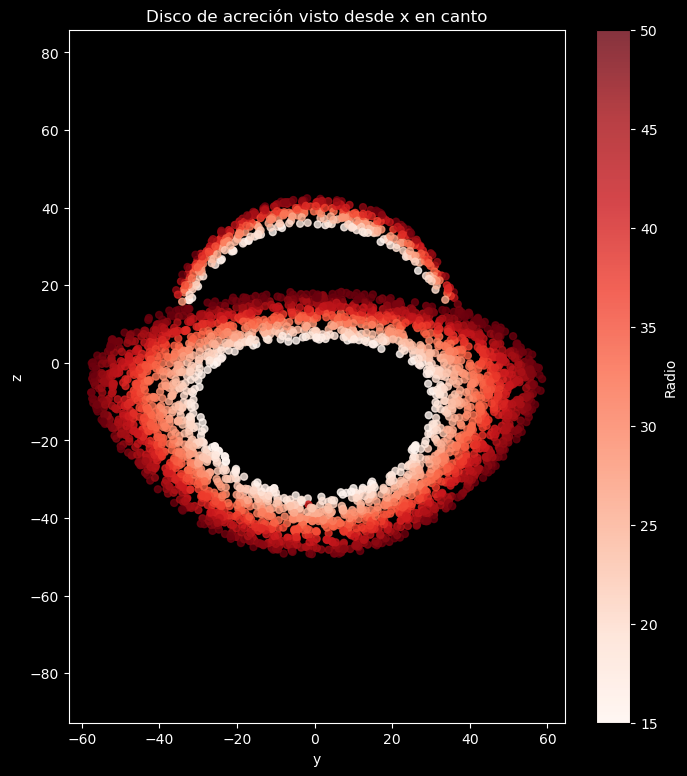

In [304]:
plt.figure(figsize=(8, 9), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(y[golpeo], z[golpeo], s=25, c=intersecciones[golpeo], cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label('Radio', color='white')
cbar.ax.tick_params(colors='white')

plt.title('Disco de acreción visto desde x en canto', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
plt.savefig('imagenes_bacanas/agujero_negro.png', dpi=300, bbox_inches='tight')
plt.show()
